# Griffiths QM
## Chapter 6 — Visualizations

| Section | Problem |
|:--|:--|
| §6.5–6.6 | Bloch's theorem — Kronig-Penney band structure |
| §6.17 | 3D isotropic HO — degeneracy and angular momentum |
| §6.20 | 2D isotropic HO — degeneracy and angular momentum |
| §6.31 | Quantum beats — superposition and expectation value oscillation |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
})
BLUE = '#2471a3'; RED = '#c0392b'; GREEN = '#1e8449'
GRAY = '#7f8c8d'; NAVY = '#1a3a5c'; PURP = '#8e44ad'; ORG = '#d35400'

figures = []
print('Setup complete.')

Setup complete.


---
## Problems 6.5 & 6.6 — Bloch's Theorem and Kronig-Penney Band Structure {#md_6_5}

Show that a periodic potential $V(x+a)=V(x)$ forces eigenstates into Bloch form $\psi_k(x)=e^{ikx}u_k(x)$, and compute the band structure for the Kronig-Penney model (periodic delta barriers).

P = 1.500pi
Fraction allowed: 0.626
RHS(q->0) = 5.7124  (>1 -> gap at E=0)
Bands found: 6
  Band 1: E = 5.1 ~ 9.9
  Band 2: E = 22.2 ~ 39.5
  Band 3: E = 55.0 ~ 88.8
  Band 4: E = 105.8 ~ 157.9
  Band 5: E = 175.6 ~ 246.7


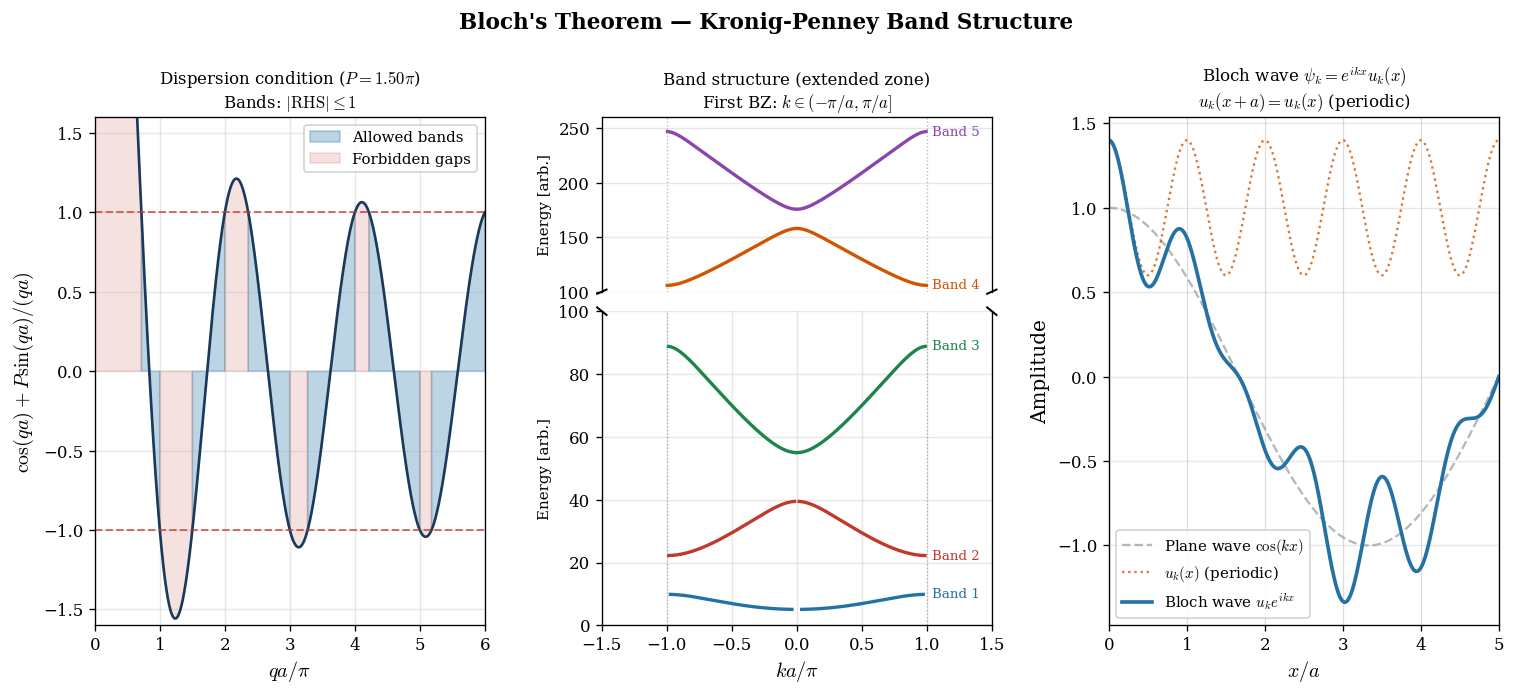

Fig 6.5-6.6 done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

P = 3*np.pi/2
q_arr = np.linspace(1e-4, 6*np.pi, 6000)
rhs     = np.cos(q_arr) + P*np.sin(q_arr)/q_arr
allowed = np.abs(rhs) <= 1.0
E_arr   = q_arr**2
k_arr   = np.where(allowed, np.arccos(np.clip(rhs,-1,1)), np.nan)

print(f'P = {P/np.pi:.3f}pi')
print(f'Fraction allowed: {allowed.mean():.3f}')
rhs_0 = np.cos(1e-3) + P*np.sin(1e-3)/1e-3
print(f'RHS(q->0) = {rhs_0:.4f}  (>1 -> gap at E=0)')

# Band ranges
gaps = np.where(np.diff(allowed.astype(int))!=0)[0]
band_ranges = []
start = 0; in_band = allowed[0]
for g in gaps:
    if in_band: band_ranges.append((start, g+1))
    in_band = not in_band; start = g+1
if in_band: band_ranges.append((start, len(allowed)))

print(f'Bands found: {len(band_ranges)}')
for bi, (s, e) in enumerate(band_ranges[:5]):
    v = ~np.isnan(k_arr[s:e])
    if v.any():
        print(f'  Band {bi+1}: E = {E_arr[s:e][v].min():.1f} ~ {E_arr[s:e][v].max():.1f}')

fig = plt.figure(figsize=(13, 5.5))
gs  = GridSpec(1, 3, figure=fig, left=0.07, right=0.97, wspace=0.30)
fig.suptitle("Bloch's Theorem — Kronig-Penney Band Structure",
             fontsize=13, fontweight='bold', y=1.04)

BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
GRAY='#7f8c8d'; ORG='#d35400'; PURP='#8e44ad'
band_cols = [BLUE, RED, GREEN, ORG, PURP]

# ── Left: dispersion condition ────────────────────────────────
ax = fig.add_subplot(gs[0])
ax.plot(q_arr/np.pi, rhs, color='#1a3a5c', lw=1.6)
ax.fill_between(q_arr/np.pi, rhs, where=allowed,
                alpha=0.30, color=BLUE, label='Allowed bands')
ax.fill_between(q_arr/np.pi, rhs, where=~allowed,
                alpha=0.15, color=RED,  label='Forbidden gaps')
ax.axhline( 1, color=RED, lw=1.2, ls='--', alpha=0.7)
ax.axhline(-1, color=RED, lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel(r'$qa/\pi$', labelpad=3)
ax.set_ylabel(r'$\cos(qa)+P\sin(qa)/(qa)$')
ax.set_title(fr'Dispersion condition ($P={P/np.pi:.2f}\pi$)'+
             '\n'+r'Bands: $|\mathrm{RHS}|\leq1$', fontsize=10)
ax.legend(fontsize=9, framealpha=0.85)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 6); ax.set_ylim(-1.6, 1.6)

# ── Middle: broken-axis band structure ────────────────────────
gs_mid  = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1],
                                  height_ratios=[1, 1.8], hspace=0.08)
ax2_top = fig.add_subplot(gs_mid[0])   # Band 4-5
ax2_bot = fig.add_subplot(gs_mid[1])   # Band 1-3

for bi, (s, e) in enumerate(band_ranges[:5]):
    col = band_cols[bi % len(band_cols)]
    k_s = k_arr[s:e]; E_s = E_arr[s:e]
    v   = ~np.isnan(k_s)
    if not v.any(): continue
    k_v = k_s[v]; E_v = E_s[v]
    ax = ax2_top if bi >= 3 else ax2_bot
    ax.plot( k_v/np.pi, E_v, color=col, lw=2.0)
    ax.plot(-k_v/np.pi, E_v, color=col, lw=2.0)

    # Label at k/pi = +1 (right zone boundary), consistent for all bands
    idx_r    = np.argmin(np.abs(k_v/np.pi - 1.0))
    ax.text(1.0 + 0.04, E_v[idx_r],
            f'Band {bi+1}', color=col, fontsize=8, va='center')

ax2_bot.set_ylim(0,   100)
ax2_top.set_ylim(100, 260)

for ax in [ax2_top, ax2_bot]:
    ax.axvline( 1, color=GRAY, lw=0.8, ls=':', alpha=0.6)
    ax.axvline(-1, color=GRAY, lw=0.8, ls=':', alpha=0.6)
    ax.set_xlim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r'Energy [arb.]', fontsize=9)

ax2_bot.set_xlabel(r'$ka/\pi$', labelpad=3)
ax2_top.set_xticks([])

# Broken-axis diagonal markers
d = 0.012
for ax, y_side in [(ax2_top, 'bottom'), (ax2_bot, 'top')]:
    sign = -1 if y_side == 'bottom' else +1
    y0   = 0 if y_side == 'bottom' else 1
    kw   = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1.2)
    ax.plot((-d, +d), (y0 + sign*d, y0 - sign*d), **kw)
    ax.plot((1-d, 1+d), (y0 + sign*d, y0 - sign*d), **kw)

ax2_top.spines['bottom'].set_visible(False)
ax2_bot.spines['top'].set_visible(False)

ax2_top.set_title('Band structure (extended zone)\n'
                  r'First BZ: $k\in(-\pi/a,\pi/a]$', fontsize=10)

# ── Right: Bloch wave illustration ───────────────────────────
ax3 = fig.add_subplot(gs[2])
x_bl  = np.linspace(0, 5, 1000)
k_b   = 0.3*np.pi
u_k   = 1 + 0.4*np.cos(2*np.pi*x_bl)
plane = np.cos(k_b*x_bl)
bloch = u_k * np.cos(k_b*x_bl)

ax3.plot(x_bl, plane, color=GRAY, lw=1.4, ls='--', alpha=0.6,
         label=r'Plane wave $\cos(kx)$')
ax3.plot(x_bl, u_k,   color=ORG,  lw=1.4, ls=':', alpha=0.8,
         label=r'$u_k(x)$ (periodic)')
ax3.plot(x_bl, bloch, color=BLUE, lw=2.2,
         label=r'Bloch wave $u_k e^{ikx}$')
for n in range(6):
    ax3.axvline(n, color=GRAY, lw=0.6, ls=':', alpha=0.3)
ax3.set_xlabel(r'$x/a$', labelpad=3)
ax3.set_ylabel('Amplitude')
ax3.set_title(r'Bloch wave $\psi_k=e^{ikx}u_k(x)$'+'\n'+
              r'$u_k(x+a)=u_k(x)$ (periodic)', fontsize=10)
ax3.legend(fontsize=9, framealpha=0.85)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 5)

figures.append((fig, 'fig_6_bloch.png'))
plt.show()
print('Fig 6.5-6.6 done.')

---
## Problem 6.17 — 3D Isotropic HO: Degeneracy and Angular Momentum {#md_6_17}

Energy levels $E_N=(N+3/2)\hbar\omega$, degeneracy $g_N=(N+1)(N+2)/2$. Angular momentum channels: $\ell=N,N-2,\ldots$

3D HO degeneracy:
  N=0: E=1.5hw, g=1, ells=[0], sum(2l+1)=1  OK
  N=1: E=2.5hw, g=3, ells=[1], sum(2l+1)=3  OK
  N=2: E=3.5hw, g=6, ells=[0, 2], sum(2l+1)=6  OK
  N=3: E=4.5hw, g=10, ells=[1, 3], sum(2l+1)=10  OK
  N=4: E=5.5hw, g=15, ells=[0, 2, 4], sum(2l+1)=15  OK


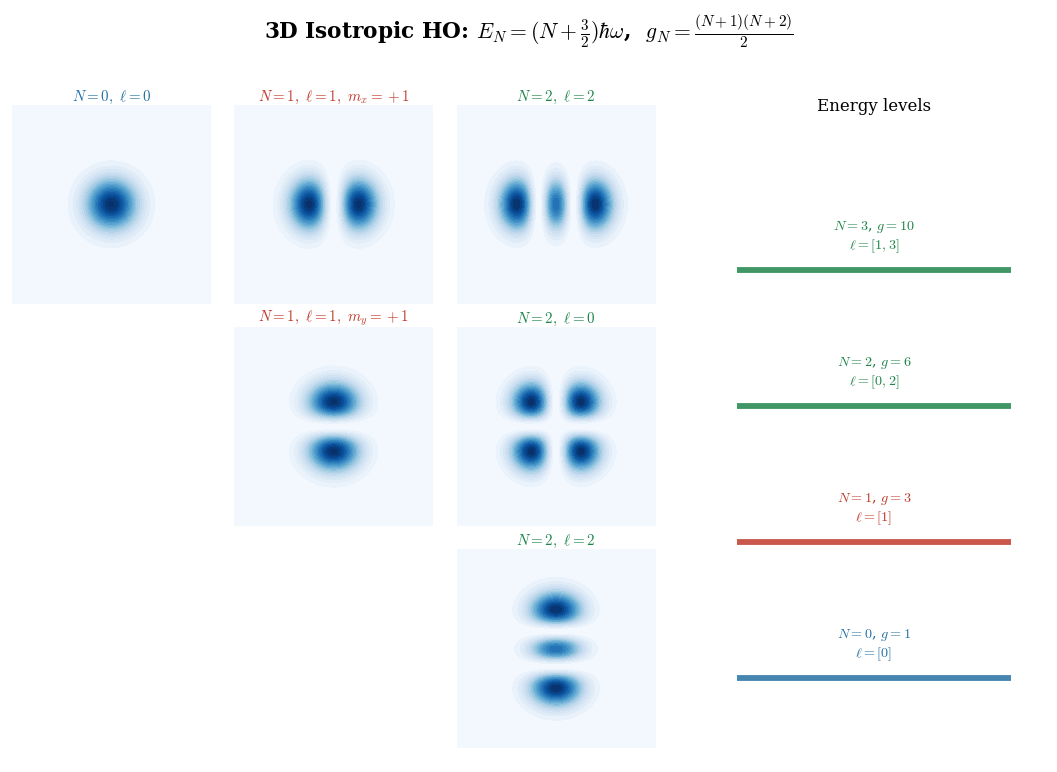

Fig 6.17 done.


In [3]:
from scipy.special import hermite, factorial as scipy_fact

def ho_1d(n, x):
    Hn   = hermite(n)
    norm = 1/np.sqrt(2**n * scipy_fact(n) * np.sqrt(np.pi))
    return norm * np.exp(-x**2/2) * Hn(x)

xi = np.linspace(-4, 4, 200)
X2, Y2 = np.meshgrid(xi, xi)

print('3D HO degeneracy:')
for N in range(5):
    g       = (N+1)*(N+2)//2
    ells    = list(range(N%2, N+1, 2))
    g_check = sum(2*l+1 for l in ells)
    print(f'  N={N}: E={(N+1.5):.1f}hw, g={g}, ells={ells}, '
          f'sum(2l+1)={g_check}  {"OK" if g==g_check else "WRONG"}')

# N=0: 1 state, N=1: 2 states, N=2: 3 states
# col 0 = N=0, col 1 = N=1, col 2 = N=2  (same layout as Fig 6.20)
states_viz = [
    (0, 0, 0, r'$N=0,\ \ell=0$'),
    (1, 0, 1, r'$N=1,\ \ell=1,\ m_x{=}+1$'),
    (0, 1, 1, r'$N=1,\ \ell=1,\ m_y{=}+1$'),
    (2, 0, 2, r'$N=2,\ \ell=2$'),
    (1, 1, 2, r'$N=2,\ \ell=0$'),
    (0, 2, 2, r'$N=2,\ \ell=2$'),
]

BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
col_N = {0: BLUE, 1: RED, 2: GREEN}

fig_w, fig_h = 13.0, 6.5
fig = plt.figure(figsize=(fig_w, fig_h))

# ── Identical geometry to Fig 6.20 ────────────────────────────
p_h      = 0.255
p_w      = p_h * (fig_h / fig_w)
gap_h    = 0.030
gap_w    = gap_h * (fig_h / fig_w)
x0_start = 0.030
y_top    = 0.920

def panel_rect(ci, ri):
    left   = x0_start + ci*(p_w + gap_w)
    bottom = y_top - (ri+1)*p_h - ri*gap_h
    return [left, bottom, p_w, p_h]

# col = N, row = state index within that N  (same as Fig 6.20)
positions = [
    (0, 0),   # N=0, ell=0       → col 0, row 0
    (1, 0),   # N=1, mx=+1       → col 1, row 0
    (1, 1),   # N=1, my=+1       → col 1, row 1
    (2, 0),   # N=2, ell=2 (a)   → col 2, row 0
    (2, 1),   # N=2, ell=0       → col 2, row 1
    (2, 2),   # N=2, ell=2 (b)   → col 2, row 2
]

for (nx, ny, N, lbl), (ci, ri) in zip(states_viz, positions):
    ax   = fig.add_axes(panel_rect(ci, ri))
    prob = (ho_1d(nx, X2) * ho_1d(ny, Y2))**2
    ax.contourf(xi, xi, prob, levels=25, cmap='Blues', vmin=0, vmax=prob.max())
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(lbl, fontsize=9, color=col_N[N], pad=3, fontweight='bold')

# ── Energy level diagram ───────────────────────────────────────
panels_right   = x0_start + 3*p_w + 2*gap_w
ax_e = fig.add_axes([panels_right + 0.03, 0.08, 0.22, 0.82])
ax_e.set_xlim(0, 1); ax_e.set_ylim(0.9, 5.6)
for sp in ax_e.spines.values(): sp.set_visible(False)
ax_e.set_xticks([]); ax_e.set_yticks([])
ax_e.set_title('Energy levels', fontsize=10, pad=6)

col_e = {0: BLUE, 1: RED, 2: GREEN, 3: GREEN}
for N in range(4):
    E    = N + 1.5
    col  = col_e[N]
    g    = (N+1)*(N+2)//2
    ells = list(range(N%2, N+1, 2))
    ax_e.hlines(E, 0.10, 0.90, colors=col, lw=3.5, alpha=0.85)
    ax_e.text(0.50, E + 0.12,
              fr'$N={N}$, $g={g}$' + '\n' + fr'$\ell={ells}$',
              ha='center', va='bottom', fontsize=8.5, color=col)

# ── Title centred over content ─────────────────────────────────
diag_right      = panels_right + 0.03 + 0.22
content_centre  = (x0_start + diag_right) / 2
fig.suptitle(r'3D Isotropic HO: $E_N=(N+\frac{3}{2})\hbar\omega$,'
             r'  $g_N=\frac{(N+1)(N+2)}{2}$',
             fontsize=13, fontweight='bold',
             y=1.04, x=content_centre)

figures.append((fig, 'fig_6_ho3d.png'))
plt.show()
print('Fig 6.17 done.')

---
## Problem 6.20 — 2D Isotropic HO: Degeneracy and Angular Momentum {#md_6_20}

Energy levels $E_N=(N+1)\hbar\omega$, degeneracy $g_N=N+1$. Angular momentum $m=N,N-2,\ldots,-N$ (step 2).

2D HO degeneracy:
  N=0: E=1hw, g=1, m=[0]  OK
  N=1: E=2hw, g=2, m=[-1, 1]  OK
  N=2: E=3hw, g=3, m=[-2, 0, 2]  OK
  N=3: E=4hw, g=4, m=[-3, -1, 1, 3]  OK
  N=4: E=5hw, g=5, m=[-4, -2, 0, 2, 4]  OK


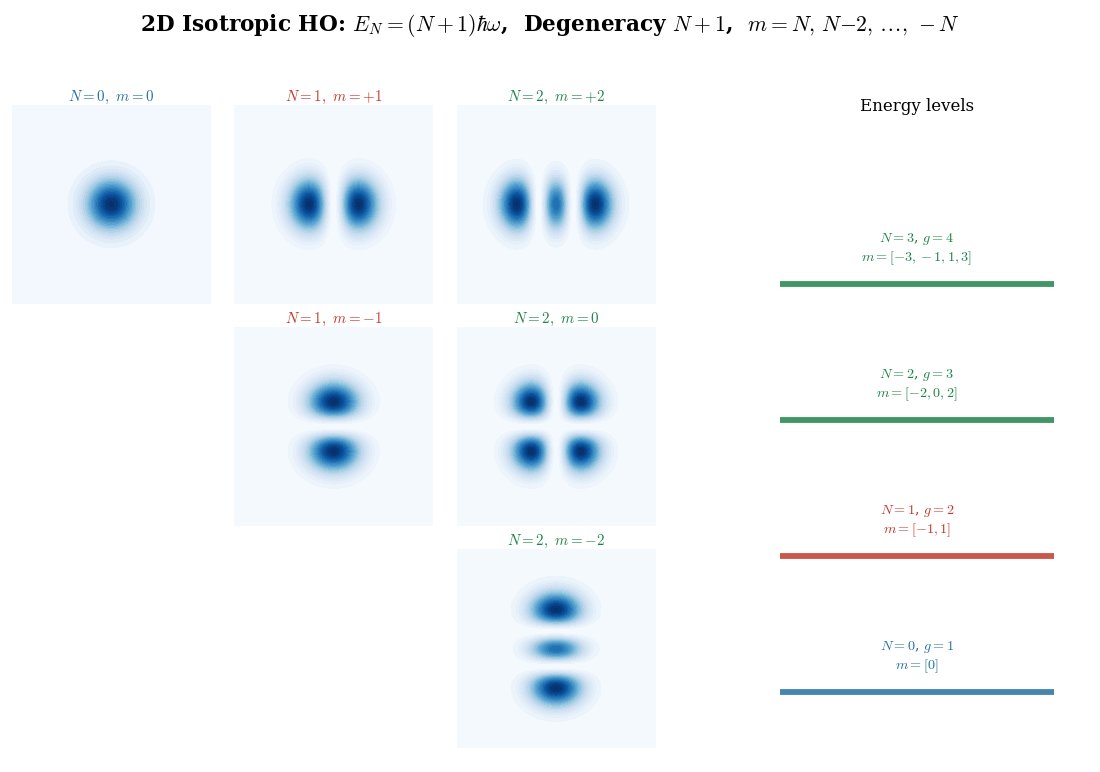

Fig 6.20 done.


In [4]:
def ho_1d(n, x):
    from scipy.special import hermite
    import math
    Hn   = hermite(n)
    norm = 1/np.sqrt(2**n * math.factorial(n) * np.sqrt(np.pi))
    return norm * np.exp(-x**2/2) * Hn(x)

xi = np.linspace(-4, 4, 300)
X2, Y2 = np.meshgrid(xi, xi)

print('2D HO degeneracy:')
for N in range(5):
    g      = N + 1
    m_vals = list(range(-N, N+1, 2))
    print(f'  N={N}: E={(N+1):.0f}hw, g={g}, m={m_vals}  OK')

states_2d = [
    (0, 0, 0,  0, r'$N=0,\ m=0$'),
    (1, 0, 1,  1, r'$N=1,\ m=+1$'),
    (0, 1, 1, -1, r'$N=1,\ m=-1$'),
    (2, 0, 2,  2, r'$N=2,\ m=+2$'),
    (1, 1, 2,  0, r'$N=2,\ m=0$'),
    (0, 2, 2, -2, r'$N=2,\ m=-2$'),
]

BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
col_N = {0: BLUE, 1: RED, 2: GREEN}

fig_w, fig_h = 13.0, 6.5
fig = plt.figure(figsize=(fig_w, fig_h))
fig.suptitle(r'2D Isotropic HO: $E_N=(N+1)\hbar\omega$,  '
             r'Degeneracy $N+1$,  $m=N,\,N{-}2,\,\ldots,\,-N$',
             fontsize=13, fontweight='bold', y=1.04, x=0.375)

# ── Square panels with identical x/y gap (in inches) ──────────
p_h    = 0.255          # panel height  [figure fraction]  = 0.255*6.5 = 1.66 in
p_w    = p_h*(fig_h/fig_w)   # panel width   [figure fraction]  = 0.128  → 1.66 in (square)
gap    = 0.030          # gap [figure fraction] in both directions = 0.030*6.5 = 0.195 in ≈ 0.030*13 = 0.39 in
# → to equalise in inches: gap_w = gap*(fig_h/fig_w)
gap_h  = gap
gap_w  = gap * (fig_h / fig_w)

x0_start = 0.030
y_top    = 0.920        # top of first row (row 0)

def panel_rect(ci, ri):
    """[left, bottom, width, height]; ri=0 → topmost row."""
    left   = x0_start + ci*(p_w + gap_w)
    bottom = y_top - (ri+1)*p_h - ri*gap_h
    return [left, bottom, p_w, p_h]

# (col, row)
positions = [
    (0, 0),   # N=0, m=0
    (1, 0),   # N=1, m=+1
    (1, 1),   # N=1, m=-1
    (2, 0),   # N=2, m=+2
    (2, 1),   # N=2, m=0
    (2, 2),   # N=2, m=-2
]

for (nx, ny, N, m, lbl), (ci, ri) in zip(states_2d, positions):
    ax   = fig.add_axes(panel_rect(ci, ri))
    prob = (ho_1d(nx, X2) * ho_1d(ny, Y2))**2
    ax.contourf(xi, xi, prob, levels=30, cmap='Blues', vmin=0, vmax=prob.max())
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(lbl, fontsize=9, color=col_N[N], pad=3, fontweight='bold')

# ── Energy level diagram ──────────────────────────────────────
# ax_e = fig.add_axes([0.77, 0.08, 0.20, 0.82])
ax_e = fig.add_axes([0.50, 0.08, 0.22, 0.82])
ax_e.set_xlim(0, 1); ax_e.set_ylim(0.5, 5.2)
for sp in ax_e.spines.values(): sp.set_visible(False)
ax_e.set_xticks([]); ax_e.set_yticks([])
ax_e.set_title('Energy levels', fontsize=10, pad=6)

col_e = {0: BLUE, 1: RED, 2: GREEN, 3: GREEN}
for N in range(4):
    E      = N + 1
    col    = col_e[N]
    m_vals = list(range(-N, N+1, 2))
    ax_e.hlines(E, 0.10, 0.90, colors=col, lw=3.5, alpha=0.85)
    ax_e.text(0.50, E + 0.13,
              fr'$N={N}$, $g={N+1}$' + '\n' + fr'$m={m_vals}$',
              ha='center', va='bottom', fontsize=8.5, color=col)

figures.append((fig, 'fig_6_ho2d.png'))
plt.show()
print('Fig 6.20 done.')

---
## Problem 6.31 — Quantum Beats: Superposition and Expectation Value Oscillation {#md_6_31}

Starting from $|\Psi(0)\rangle=(\psi_1+\psi_2)/\sqrt{2}$ in the ISW, $\langle x\rangle(t)$ oscillates at $\omega_{21}=(E_2-E_1)/\hbar$.

omega_21 = 3*pi^2/2 = 14.80441
T_beat = 0.42441  (= 2pi/omega_21)
<psi2|x|psi1> = 0.180127
Norm check: min=1.000000, max=1.000000  OK


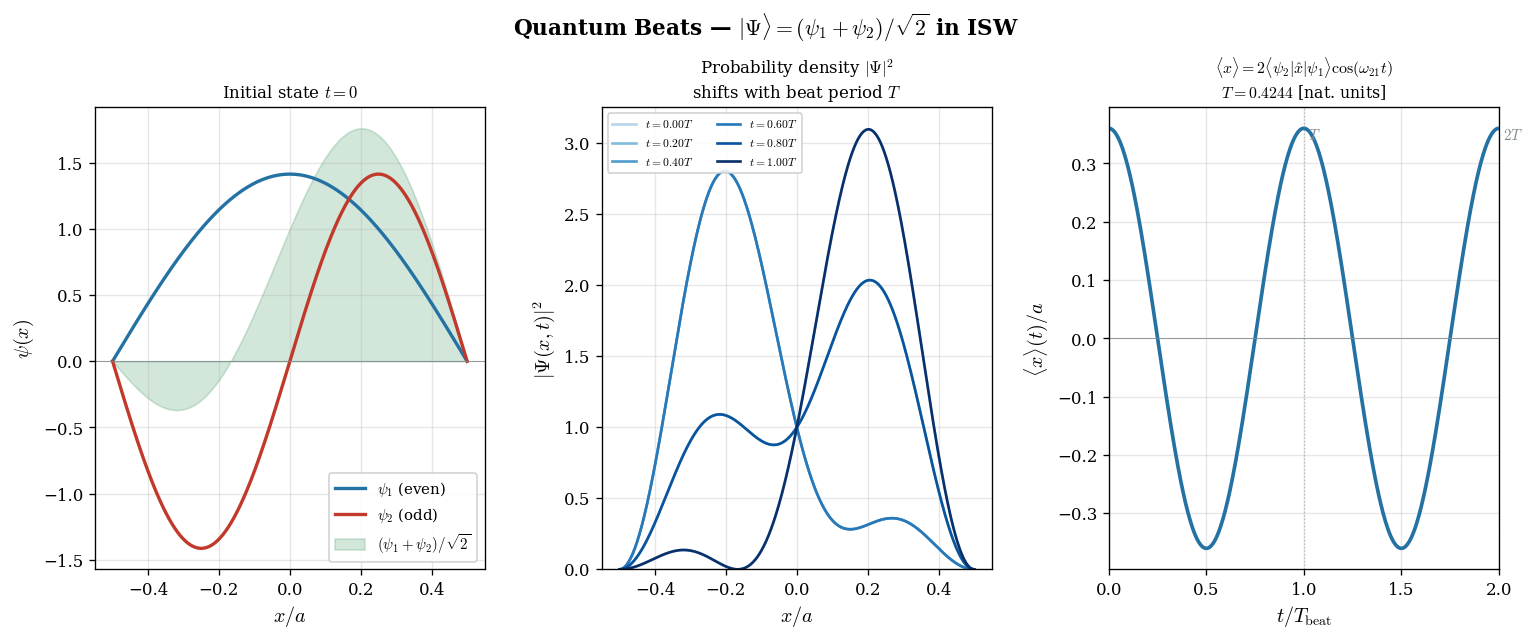

Fig 6.31 done.


In [5]:
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; ORG='#d35400'

# ISW centred at origin: psi_n(x)
a = 1.0
x = np.linspace(-a/2, a/2, 1000)

def psi_isw(n, x, a=1.0):
    if n % 2 == 1:
        return np.sqrt(2/a)*np.cos(n*np.pi*x/a)
    else:
        return np.sqrt(2/a)*np.sin(n*np.pi*x/a)

# Natural units: hbar=1, 2m=1, a=1 -> E_n = n^2*pi^2/2
# E_1 = pi^2/2, E_2 = 4*pi^2/2 = 2*pi^2
# omega_21 = (E_2-E_1)/hbar = 3*pi^2/2
E1_n = np.pi**2/2; E2_n = 2*np.pi**2
omega21 = E2_n - E1_n   # = 3*pi^2/2
T_beat  = 2*np.pi/omega21

psi1 = psi_isw(1, x); psi2 = psi_isw(2, x)

# Matrix element <psi2|x|psi1>
x21 = np.trapezoid(psi2*x*psi1, x)
print(f'omega_21 = 3*pi^2/2 = {omega21:.5f}')
print(f'T_beat = {T_beat:.5f}  (= 2pi/omega_21)')
print(f'<psi2|x|psi1> = {x21:.6f}')

# <x>(t) = a/2 + 2*x21*cos(omega21*t)  [well centred at 0 → <x>_nn=0]
t_arr = np.linspace(0, 2*T_beat, 500)
x_exp = 2*x21*np.cos(omega21*t_arr)   # <x>_11=<x>_22=0 by parity

# Check: norm at all times
norms = []
for t in t_arr[:10]:
    phase = np.exp(-1j*E1_n*t); phase2 = np.exp(-1j*E2_n*t)
    Psi = (psi1*phase + psi2*phase2)/np.sqrt(2)
    norms.append(np.trapezoid(np.abs(Psi)**2, x))
print(f'Norm check: min={min(norms):.6f}, max={max(norms):.6f}  OK')

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07,right=0.97,wspace=0.30))
fig.suptitle(r'Quantum Beats — $|\Psi\rangle=(\psi_1+\psi_2)/\sqrt{2}$ in ISW',
             fontsize=13, fontweight='bold', y=1.04)

# Left: wavefunctions
ax = axes[0]
ax.plot(x/a, psi1, color=BLUE, lw=2.0, label=r'$\psi_1$ (even)')
ax.plot(x/a, psi2, color=RED,  lw=2.0, label=r'$\psi_2$ (odd)')
ax.fill_between(x/a, (psi1+psi2)/np.sqrt(2), alpha=0.2, color=GREEN,
                label=r'$(\psi_1+\psi_2)/\sqrt{2}$')
ax.axhline(0, color=GRAY, lw=0.5)
ax.set_xlabel(r'$x/a$', labelpad=3); ax.set_ylabel(r'$\psi(x)$')
ax.set_title('Initial state $t=0$', fontsize=10)
ax.legend(fontsize=9, framealpha=0.85); ax.grid(True, alpha=0.3); ax.set_xlim(-0.55,0.55)

# Middle: |Psi(x,t)|^2 at several times
ax2 = axes[1]
t_snaps = np.linspace(0, T_beat, 6)
cols_t = plt.cm.Blues(np.linspace(0.3,1.0,len(t_snaps)))
for t, col in zip(t_snaps, cols_t):
    phase1 = np.exp(-1j*E1_n*t); phase2 = np.exp(-1j*E2_n*t)
    Psi = (psi1*phase1 + psi2*phase2)/np.sqrt(2)
    prob = np.abs(Psi)**2
    ax2.plot(x/a, prob, color=col, lw=1.6, label=fr'$t={t/T_beat:.2f}T$')
ax2.set_xlabel(r'$x/a$', labelpad=3); ax2.set_ylabel(r'$|\Psi(x,t)|^2$')
ax2.set_title(r'Probability density $|\Psi|^2$' + '\nshifts with beat period $T$', fontsize=10)
ax2.legend(fontsize=7, framealpha=0.85, ncol=2); ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.55,0.55); ax2.set_ylim(bottom=0)

# Right: <x>(t)
ax3 = axes[2]
ax3.plot(t_arr/T_beat, x_exp/a, color=BLUE, lw=2.2)
ax3.axhline(0, color=GRAY, lw=0.5)
ax3.axvline(1, color=GRAY, lw=0.8, ls=':', alpha=0.5)
ax3.axvline(2, color=GRAY, lw=0.8, ls=':', alpha=0.5)
ax3.text(1.02, 0.95*x_exp.max()/a, r'$T$', color=GRAY, fontsize=9)
ax3.text(2.02, 0.95*x_exp.max()/a, r'$2T$', color=GRAY, fontsize=9)
ax3.set_xlabel(r'$t / T_{\rm beat}$', labelpad=3)
ax3.set_ylabel(r'$\langle x\rangle(t)/a$')
ax3.set_title(r'$\langle x\rangle=2\langle\psi_2|\hat{x}|\psi_1\rangle\cos(\omega_{21}t)$' + '\n'
              fr'$T={T_beat:.4f}$ [nat. units]', fontsize=9.5)
ax3.grid(True, alpha=0.3); ax3.set_xlim(0, 2)

figures.append((fig, 'fig_6_beats.png'))
plt.show()
print('Fig 6.31 done.')


In [6]:
# ── Download all figures ────────────────────────────────────────
import os, zipfile

save_dir = 'ch06_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch06_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch06_figures/fig_6_bloch.png
Saved: ch06_figures/fig_6_ho3d.png
Saved: ch06_figures/fig_6_ho2d.png
Saved: ch06_figures/fig_6_beats.png
Zip: ch06_figures.zip,  Files: ['fig_6_bloch.png', 'fig_6_ho3d.png', 'fig_6_ho2d.png', 'fig_6_beats.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
